In [ ]:
!pip -q install stanza

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.0/2.0 MB 19.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 794.2/794.2 kB 16.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 610.9/610.9 kB 10.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 418.7/418.7 kB 11.5 MB/s eta 0:00:00


In [ ]:
import requests
import os

os.makedirs("ud_data", exist_ok=True)

urls = {
    "English": "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-test.conllu",
    "German": "https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-test.conllu"
}

for language, url in urls.items():
    filename = f"ud_data/{language.lower()}_test.conllu"

    response = requests.get(url)

    if response.status_code == 200:
        with open(filename, "wb") as f:
            f.write(response.content)
        print(f"{language}: downloaded successfully")
    else:
        print(f"{language}: download failed ({response.status_code})")

English: downloaded successfully
German: downloaded successfully


In [ ]:
import conllu
import pandas as pd

def load_conllu(path):
    with open(path, "r", encoding="utf-8") as f:
        return conllu.parse(f.read())

english_sentences = load_conllu("ud_data/english_test.conllu")
german_sentences = load_conllu("ud_data/german_test.conllu")

print("English sentences:", len(english_sentences))
print("German sentences:", len(german_sentences))

English sentences: 2077
German sentences: 977


In [ ]:
print("First English sentence:")
print(english_sentences[0].metadata)
print(english_sentences[0].serialize())

print("\n" + "="*60 + "\n")

print("First German sentence:")
print(german_sentences[0].metadata)
print(german_sentences[0].serialize())

First English sentence:
{'newdoc id': 'weblog-blogspot.com_zentelligence_20040423000200_ENG_20040423_000200', 'sent_id': 'weblog-blogspot.com_zentelligence_20040423000200_ENG_20040423_000200-0001', 'newpar id': 'weblog-blogspot.com_zentelligence_20040423000200_ENG_20040423_000200-p0001', 'text': 'What if Google Morphed Into GoogleOS?'}
# newdoc id = weblog-blogspot.com_zentelligence_20040423000200_ENG_20040423_000200
# sent_id = weblog-blogspot.com_zentelligence_20040423000200_ENG_20040423_000200-0001
# newpar id = weblog-blogspot.com_zentelligence_20040423000200_ENG_20040423_000200-p0001
# text = What if Google Morphed Into GoogleOS?
1	What	what	PRON	WP	PronType=Int	0	root	0:root	Cxn=Conditional-Interrogative|CxnElt=1:Conditional-Interrogative.Apodosis
2	if	if	SCONJ	IN	_	4	mark	4:mark	_
3	Google	Google	PROPN	NNP	Number=Sing	4	nsubj	4:nsubj	_
4	Morphed	morph	VERB	VBD	Mood=Ind|Number=Sing|Person=3|Tense=Past|VerbForm=Fin	1	advcl	1:advcl:if	CxnElt=1:Conditional-Interrogative.Protasis
5	I

In [ ]:
def extract_dependencies(sentences, language):
    rows = []

    for sentence in sentences:
        for token in sentence:

            if not isinstance(token["id"], int):
                continue

            head = token["head"]

            if head is None or head == 0:
                continue

            distance = abs(token["id"] - head)

            rows.append({
                "language": language,
                "sentence_id": sentence.metadata.get("sent_id", ""),
                "word": token["form"],
                "upos": token["upos"],
                "dependency": token["deprel"],
                "token_id": token["id"],
                "head_id": head,
                "distance": distance
            })

    return pd.DataFrame(rows)


english_df = extract_dependencies(
    english_sentences,
    "English"
)

german_df = extract_dependencies(
    german_sentences,
    "German"
)

print("English dependencies:", len(english_df))
print("German dependencies:", len(german_df))

print("\nEnglish:")
display(english_df.head())

print("\nGerman:")
display(german_df.head())

English dependencies: 23017
German dependencies: 15522

English:


,language,sentence_id,word,upos,dependency,token_id,head_id,distance
0,English,weblog-blogspot.com_zentelligence_200404230002...,if,SCONJ,mark,2,4,2
1,English,weblog-blogspot.com_zentelligence_200404230002...,Google,PROPN,nsubj,3,4,1
2,English,weblog-blogspot.com_zentelligence_200404230002...,Morphed,VERB,advcl,4,1,3
3,English,weblog-blogspot.com_zentelligence_200404230002...,Into,ADP,case,5,6,1
4,English,weblog-blogspot.com_zentelligence_200404230002...,GoogleOS,PROPN,obl,6,4,2



German:


,language,sentence_id,word,upos,dependency,token_id,head_id,distance
0,German,test-s1,Der,DET,det,1,2,1
1,German,test-s1,Hauptgang,NOUN,nsubj,2,5,3
2,German,test-s1,war,AUX,cop,3,5,2
3,German,test-s1,in,ADP,case,4,5,1
4,German,test-s1,",",PUNCT,punct,6,8,2


In [ ]:

all_dependencies = pd.concat(
    [english_df, german_df],
    ignore_index=True
)


distance_summary = (
    all_dependencies
    .groupby("language")["distance"]
    .describe()
)

display(distance_summary)

,count,mean,std,min,25%,50%,75%,max
language,,,,,,,,
English,23017.0,3.196724,4.328046,1.0,1.0,2.0,3.0,76.0
German,15522.0,3.785788,4.558313,1.0,1.0,2.0,4.0,55.0


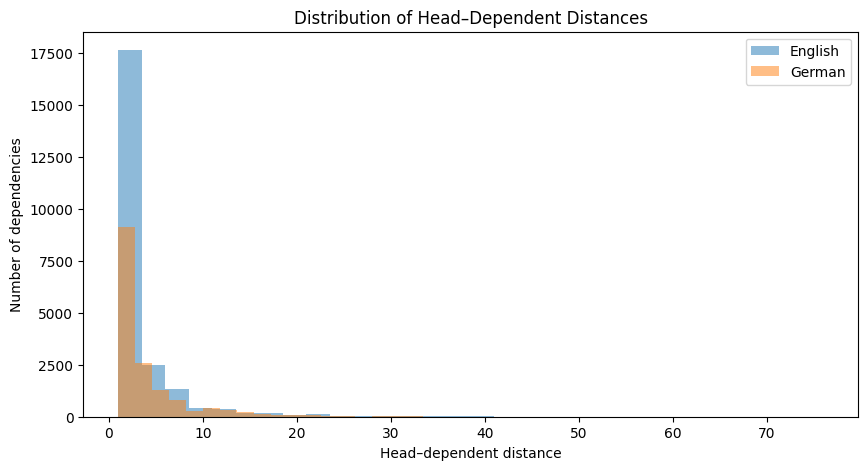

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

for language in ["English", "German"]:
    data = all_dependencies[
        all_dependencies["language"] == language
    ]["distance"]

    plt.hist(
        data,
        bins=30,
        alpha=0.5,
        label=language
    )

plt.xlabel("Head–dependent distance")
plt.ylabel("Number of dependencies")
plt.title("Distribution of Head–Dependent Distances")
plt.legend()
plt.show()

In [ ]:
import stanza

stanza.download("en")
stanza.download("de")

print("English and German models downloaded.")

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: en (English) ...


models/default.zip: reconstructing file:   0%|          |  0.00B /  525MB            

models/default.zip: downloading bytes:           |  0.00B            

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/en/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources


INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/resources.json
INFO:stanza:Downloading default packages for language: de (German) ...


models/default.zip: reconstructing file:   0%|          |  0.00B /  809MB            

models/default.zip: downloading bytes:           |  0.00B            

INFO:stanza:Downloaded file to /root/.cache/stanza/1.14.0/resources/de/default.zip
INFO:stanza:Finished downloading models and saved to /root/.cache/stanza/1.14.0/resources


English and German models downloaded.


In [ ]:
import stanza


english_nlp = stanza.Pipeline(
    lang="en",
    processors="tokenize,pos,lemma,depparse",
    verbose=False
)

german_nlp = stanza.Pipeline(
    lang="de",
    processors="tokenize,pos,lemma,depparse",
    verbose=False
)


english_test = english_nlp("The researchers analyzed the data.")

print("English:")
for sentence in english_test.sentences:
    for word in sentence.words:
        print(
            word.id,
            word.text,
            "HEAD =", word.head,
            "REL =", word.deprel
        )


german_test = german_nlp("Der Forscher analysierte die Daten.")

print("\nGerman:")
for sentence in german_test.sentences:
    for word in sentence.words:
        print(
            word.id,
            word.text,
            "HEAD =", word.head,
            "REL =", word.deprel
        )

English:
1 The HEAD = 2 REL = det
2 researchers HEAD = 3 REL = nsubj
3 analyzed HEAD = 0 REL = root
4 the HEAD = 5 REL = det
5 data HEAD = 3 REL = obj
6 . HEAD = 3 REL = punct

German:
1 Der HEAD = 2 REL = det
2 Forscher HEAD = 3 REL = nsubj
3 analysierte HEAD = 0 REL = root
4 die HEAD = 5 REL = det
5 Daten HEAD = 3 REL = obj
6 . HEAD = 3 REL = punct


In [ ]:
import os
import requests

os.makedirs("ud_data", exist_ok=True)

files = {
    "english_test.conllu":
        "https://raw.githubusercontent.com/UniversalDependencies/UD_English-EWT/master/en_ewt-ud-test.conllu",

    "german_test.conllu":
        "https://raw.githubusercontent.com/UniversalDependencies/UD_German-GSD/master/de_gsd-ud-test.conllu"
}

for filename, url in files.items():
    path = os.path.join("ud_data", filename)

    response = requests.get(url)

    if response.status_code == 200:
        with open(path, "wb") as f:
            f.write(response.content)
        print(filename, "downloaded successfully")
    else:
        print(filename, "FAILED:", response.status_code)

english_test.conllu downloaded successfully
german_test.conllu downloaded successfully


In [ ]:
!pip -q install conllu

import conllu

def load_conllu(path):
    with open(path, "r", encoding="utf-8") as f:
        return conllu.parse(f.read())

english_sentences = load_conllu("ud_data/english_test.conllu")
german_sentences = load_conllu("ud_data/german_test.conllu")

print("English sentences:", len(english_sentences))
print("German sentences:", len(german_sentences))

English sentences: 2077
German sentences: 977


In [ ]:


def get_sentence_text(sentence):
    return sentence.metadata.get("text", " ".join(
        token["form"]
        for token in sentence
        if isinstance(token["id"], int)
    ))

english_sample = english_sentences[:100]
german_sample = german_sentences[:100]

english_predictions = []
german_predictions = []

print("Parsing English...")
for i, sentence in enumerate(english_sample):
    text = get_sentence_text(sentence)
    doc = english_nlp(text)
    english_predictions.append(doc)

print("English parsing completed.")

print("Parsing German...")
for i, sentence in enumerate(german_sample):
    text = get_sentence_text(sentence)
    doc = german_nlp(text)
    german_predictions.append(doc)

print("German parsing completed.")

Parsing English...
English parsing completed.
Parsing German...
German parsing completed.


In [ ]:
def check_alignment(gold_sentences, predictions, language):
    problems = []

    for i, (gold, pred_doc) in enumerate(zip(gold_sentences, predictions)):
        gold_words = [
            token["form"]
            for token in gold
            if isinstance(token["id"], int)
        ]

        pred_words = [
            word.text
            for sentence in pred_doc.sentences
            for word in sentence.words
        ]

        if gold_words != pred_words:
            problems.append(i)

    print(f"{language}: {len(problems)} alignment problems")

    if problems:
        print("First problematic sentence:", problems[0])
    else:
        print("All sentences are aligned correctly.")


check_alignment(
    english_sample,
    english_predictions,
    "English"
)

check_alignment(
    german_sample,
    german_predictions,
    "German"
)

English: 7 alignment problems
First problematic sentence: 11
German: 4 alignment problems
First problematic sentence: 14


In [ ]:
def show_alignment_problems(gold_sentences, predictions, language, max_problems=5):

    shown = 0

    for i, (gold, pred_doc) in enumerate(zip(gold_sentences, predictions)):

        gold_words = [
            token["form"]
            for token in gold
            if isinstance(token["id"], int)
        ]

        pred_words = [
            word.text
            for sentence in pred_doc.sentences
            for word in sentence.words
        ]

        if gold_words != pred_words:

            print("=" * 70)
            print(f"{language} - Sentence index: {i}")
            print()

            print("GOLD:")
            print(gold_words)

            print()
            print("PREDICTED:")
            print(pred_words)

            print()
            print("Original sentence:")
            print(gold.metadata.get("text", ""))

            shown += 1

            if shown >= max_problems:
                break


show_alignment_problems(
    english_sample,
    english_predictions,
    "English"
)

show_alignment_problems(
    german_sample,
    german_predictions,
    "German"
)

English - Sentence index: 11

GOLD:
['John', 'Donovan', 'from', 'Argghhh!', 'has', 'put', 'out', 'a', 'excellent', 'slide', 'show', 'on', 'what', 'was', 'actually', 'found', 'and', 'fought', 'for', 'in', 'Fallujah', '.']

PREDICTED:
['John', 'Donovan', 'from', 'Argghhh', '!', 'has', 'put', 'out', 'a', 'excellent', 'slide', 'show', 'on', 'what', 'was', 'actually', 'found', 'and', 'fought', 'for', 'in', 'Fallujah', '.']

Original sentence:
John Donovan from Argghhh! has put out a excellent slide show on what was actually found and fought for in Fallujah.
English - Sentence index: 13

GOLD:
['He', 'makes', 'some', 'good', 'observations', 'on', 'a', 'few', 'of', 'the', "pic's", '.']

PREDICTED:
['He', 'makes', 'some', 'good', 'observations', 'on', 'a', 'few', 'of', 'the', 'pic', "'s", '.']

Original sentence:
He makes some good observations on a few of the pic's.
English - Sentence index: 15

GOLD:
['On', 'the', 'next', 'two', 'pictures', 'he', 'took', 'screenshots', 'of', 'two', 'beheadin

In [ ]:


english_nlp_pretok = stanza.Pipeline(
    lang="en",
    processors="tokenize,pos,lemma,depparse",
    tokenize_pretokenized=True,
    verbose=False
)

german_nlp_pretok = stanza.Pipeline(
    lang="de",
    processors="tokenize,pos,lemma,depparse",
    tokenize_pretokenized=True,
    verbose=False
)

print("Pipelines created successfully.")

Pipelines created successfully.


In [ ]:
def get_gold_tokens(sentence):
    return [
        token["form"]
        for token in sentence
        if isinstance(token["id"], int)
    ]

print("get_gold_tokens is ready.")

get_gold_tokens is ready.


In [ ]:
english_predictions = []
german_predictions = []

print("Parsing English...")

for sentence in english_sample:
    tokens = get_gold_tokens(sentence)
    doc = english_nlp_pretok([tokens])
    english_predictions.append(doc)

print("English parsing completed.")

print("Parsing German...")

for sentence in german_sample:
    tokens = get_gold_tokens(sentence)
    doc = german_nlp_pretok([tokens])
    german_predictions.append(doc)

print("German parsing completed.")

Parsing English...
English parsing completed.
Parsing German...
German parsing completed.


In [ ]:
check_alignment(
    english_sample,
    english_predictions,
    "English"
)

check_alignment(
    german_sample,
    german_predictions,
    "German"
)

English: 0 alignment problems
All sentences are aligned correctly.
German: 0 alignment problems
All sentences are aligned correctly.


In [ ]:
import pandas as pd

print("Pandas is ready.")

Pandas is ready.


In [ ]:
def calculate_parsing_results(gold_sentences, predictions, language):
    rows = []

    for gold_sentence, pred_doc in zip(gold_sentences, predictions):

        gold_tokens = [
            token for token in gold_sentence
            if isinstance(token["id"], int)
        ]

        pred_words = [
            word
            for sentence in pred_doc.sentences
            for word in sentence.words
        ]

        for gold, pred in zip(gold_tokens, pred_words):

            # Ignore the artificial root
            if gold["head"] == 0:
                continue

            gold_head = gold["head"]
            pred_head = pred.head

            gold_relation = gold["deprel"]
            pred_relation = pred.deprel

            distance = abs(gold["id"] - gold_head)

            head_correct = (gold_head == pred_head)
            label_correct = (gold_relation == pred_relation)
            uas_correct = head_correct
            las_correct = head_correct and label_correct

            rows.append({
                "language": language,
                "word": gold["form"],
                "dependency": gold_relation,
                "distance": distance,
                "gold_head": gold_head,
                "pred_head": pred_head,
                "gold_relation": gold_relation,
                "pred_relation": pred_relation,
                "UAS_correct": uas_correct,
                "LAS_correct": las_correct
            })

    return pd.DataFrame(rows)


english_results = calculate_parsing_results(
    english_sample,
    english_predictions,
    "English"
)

german_results = calculate_parsing_results(
    german_sample,
    german_predictions,
    "German"
)

results = pd.concat(
    [english_results, german_results],
    ignore_index=True
)

print("Total dependencies evaluated:", len(results))

display(results.head(10))

Total dependencies evaluated: 3443


,language,word,dependency,distance,gold_head,pred_head,gold_relation,pred_relation,UAS_correct,LAS_correct
0,English,if,mark,2,4,4,mark,mark,True,True
1,English,Google,nsubj,1,4,4,nsubj,nsubj,True,True
2,English,Morphed,advcl,3,1,1,advcl,advcl,True,True
3,English,Into,case,1,6,6,case,case,True,True
4,English,GoogleOS,obl,2,4,4,obl,obl,True,True
5,English,?,punct,3,4,1,punct,punct,False,False
6,English,if,mark,2,4,4,mark,mark,True,True
7,English,Google,nsubj,1,4,4,nsubj,nsubj,True,True
8,English,expanded,advcl,3,1,1,advcl,advcl,True,True
9,English,on,case,10,15,15,case,case,True,True


In [ ]:
overall_scores = (
    results
    .groupby("language")[["UAS_correct", "LAS_correct"]]
    .mean()
    .mul(100)
    .round(2)
)

overall_scores.columns = ["UAS (%)", "LAS (%)"]

display(overall_scores)

,UAS (%),LAS (%)
language,,
English,93.01,90.77
German,90.08,85.01


In [ ]:
def distance_category(distance):
    if distance <= 2:
        return "Short (1-2)"
    elif distance <= 5:
        return "Medium (3-5)"
    elif distance <= 10:
        return "Long (6-10)"
    else:
        return "Very long (>10)"


results["distance_category"] = results["distance"].apply(
    distance_category
)

distance_results = (
    results
    .groupby(["language", "distance_category"])
    [["UAS_correct", "LAS_correct"]]
    .mean()
    .mul(100)
    .round(2)
)

distance_results.columns = ["UAS (%)", "LAS (%)"]

display(distance_results)

UAS (%)  LAS (%)
language distance_category                  
English  Long (6-10)          89.01    85.71
         Medium (3-5)         91.63    89.04
         Short (1-2)          95.53    93.50
         Very long (>10)      80.28    78.87
German   Long (6-10)          86.86    80.57
         Medium (3-5)         88.57    81.59
         Short (1-2)          91.94    88.17
         Very long (>10)      85.37    78.05

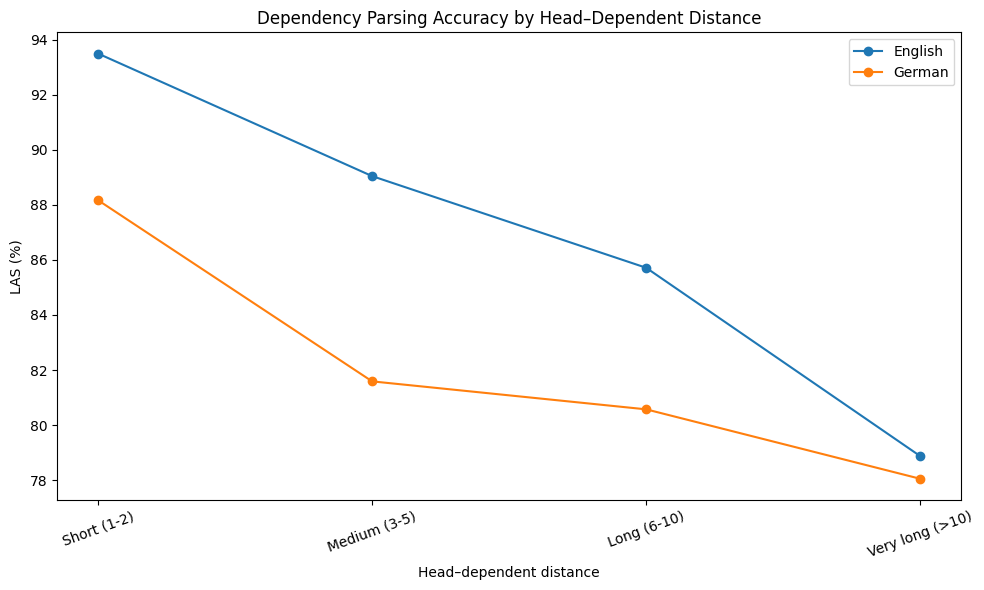

In [ ]:
import matplotlib.pyplot as plt
plot_data = (
    results
    .groupby(["language", "distance_category"])["LAS_correct"]
    .mean()
    .mul(100)
    .reset_index()
)

order = [
    "Short (1-2)",
    "Medium (3-5)",
    "Long (6-10)",
    "Very long (>10)"
]

plot_data["distance_category"] = pd.Categorical(
    plot_data["distance_category"],
    categories=order,
    ordered=True
)

plot_data = plot_data.sort_values("distance_category")

plt.figure(figsize=(10, 6))

for language in plot_data["language"].unique():
    subset = plot_data[plot_data["language"] == language]

    plt.plot(
        subset["distance_category"],
        subset["LAS_correct"],
        marker="o",
        label=language
    )

plt.xlabel("Head–dependent distance")
plt.ylabel("LAS (%)")
plt.title("Dependency Parsing Accuracy by Head–Dependent Distance")
plt.legend()
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [ ]:

english_full = english_sentences
german_full = german_sentences

print("English sentences:", len(english_full))
print("German sentences:", len(german_full))

English sentences: 2077
German sentences: 977


In [ ]:


english_predictions_full = []
german_predictions_full = []

print("Parsing all English sentences...")

for i, sentence in enumerate(english_full):
    tokens = get_gold_tokens(sentence)
    doc = english_nlp_pretok([tokens])
    english_predictions_full.append(doc)

    if (i + 1) % 250 == 0:
        print(f"English: {i + 1}/{len(english_full)}")

print("English parsing completed.")

print("\nParsing all German sentences...")

for i, sentence in enumerate(german_full):
    tokens = get_gold_tokens(sentence)
    doc = german_nlp_pretok([tokens])
    german_predictions_full.append(doc)

    if (i + 1) % 250 == 0:
        print(f"German: {i + 1}/{len(german_full)}")

print("German parsing completed.")

Parsing all English sentences...
English: 250/2077
English: 500/2077
English: 750/2077
English: 1000/2077
English: 1250/2077
English: 1500/2077
English: 1750/2077
English: 2000/2077
English parsing completed.

Parsing all German sentences...
German: 250/977
German: 500/977
German: 750/977
German parsing completed.


In [ ]:
check_alignment(
    english_full,
    english_predictions_full,
    "English"
)

check_alignment(
    german_full,
    german_predictions_full,
    "German"
)

English: 0 alignment problems
All sentences are aligned correctly.
German: 0 alignment problems
All sentences are aligned correctly.


In [ ]:
english_results_full = calculate_parsing_results(
    english_full,
    english_predictions_full,
    "English"
)

german_results_full = calculate_parsing_results(
    german_full,
    german_predictions_full,
    "German"
)

final_results = pd.concat(
    [english_results_full, german_results_full],
    ignore_index=True
)

print("Total dependencies evaluated:", len(final_results))

Total dependencies evaluated: 38539


In [ ]:
final_scores = (
    final_results
    .groupby("language")[["UAS_correct", "LAS_correct"]]
    .mean()
    .mul(100)
    .round(2)
)

final_scores.columns = ["UAS (%)", "LAS (%)"]

display(final_scores)

,UAS (%),LAS (%)
language,,
English,92.03,89.56
German,87.46,83.19


In [ ]:
final_results["distance_category"] = final_results["distance"].apply(
    distance_category
)

final_distance_results = (
    final_results
    .groupby(
        ["language", "distance_category"]
    )[["UAS_correct", "LAS_correct"]]
    .mean()
    .mul(100)
    .round(2)
)

final_distance_results.columns = ["UAS (%)", "LAS (%)"]

display(final_distance_results)

UAS (%)  LAS (%)
language distance_category                  
English  Long (6-10)          83.58    80.79
         Medium (3-5)         89.99    86.90
         Short (1-2)          94.61    92.35
         Very long (>10)      81.21    79.37
German   Long (6-10)          84.20    78.11
         Medium (3-5)         83.44    78.66
         Short (1-2)          90.46    87.25
         Very long (>10)      81.14    73.32

In [ ]:
distance_counts = (
    final_results
    .groupby(["language", "distance_category"])
    .size()
    .reset_index(name="dependencies")
)

order = [
    "Short (1-2)",
    "Medium (3-5)",
    "Long (6-10)",
    "Very long (>10)"
]

distance_counts["distance_category"] = pd.Categorical(
    distance_counts["distance_category"],
    categories=order,
    ordered=True
)

distance_counts = distance_counts.sort_values(
    ["language", "distance_category"]
)

display(distance_counts)

,language,distance_category,dependencies
2,English,Short (1-2),14759
1,English,Medium (3-5),5365
0,English,Long (6-10),1754
3,English,Very long (>10),1139
6,German,Short (1-2),9099
5,German,Medium (3-5),3322
4,German,Long (6-10),1823
7,German,Very long (>10),1278


In [ ]:

error_summary = (
    final_results
    .groupby(["language", "distance_category"])
    .agg(
        dependencies=("LAS_correct", "size"),
        LAS=("LAS_correct", "mean")
    )
    .reset_index()
)

error_summary["LAS (%)"] = (
    error_summary["LAS"] * 100
).round(2)

error_summary["Error (%)"] = (
    (1 - error_summary["LAS"]) * 100
).round(2)

display(
    error_summary[
        ["language", "distance_category",
         "dependencies", "LAS (%)", "Error (%)"]
    ]
)

,language,distance_category,dependencies,LAS (%),Error (%)
0,English,Long (6-10),1754,80.79,19.21
1,English,Medium (3-5),5365,86.90,13.10
2,English,Short (1-2),14759,92.35,7.65
3,English,Very long (>10),1139,79.37,20.63
4,German,Long (6-10),1823,78.11,21.89
5,German,Medium (3-5),3322,78.66,21.34
6,German,Short (1-2),9099,87.25,12.75
7,German,Very long (>10),1278,73.32,26.68


In [ ]:
def calculate_parsing_results(gold_sentences, predictions, language):
    rows = []

    for gold_sentence, pred_doc in zip(gold_sentences, predictions):

        gold_tokens = [
            token for token in gold_sentence
            if isinstance(token["id"], int)
        ]

        pred_words = [
            word
            for sentence in pred_doc.sentences
            for word in sentence.words
        ]

        sentence_id = gold_sentence.metadata.get(
            "sent_id",
            f"{language}_{len(rows)}"
        )

        for gold, pred in zip(gold_tokens, pred_words):

            if gold["head"] == 0:
                continue

            gold_head = gold["head"]
            pred_head = pred.head

            gold_relation = gold["deprel"]
            pred_relation = pred.deprel

            distance = abs(gold["id"] - gold_head)

            head_correct = (gold_head == pred_head)
            label_correct = (gold_relation == pred_relation)

            rows.append({
                "language": language,
                "sentence_id": sentence_id,
                "word": gold["form"],
                "dependency": gold_relation,
                "distance": distance,
                "gold_head": gold_head,
                "pred_head": pred_head,
                "gold_relation": gold_relation,
                "pred_relation": pred_relation,
                "UAS_correct": head_correct,
                "LAS_correct": head_correct and label_correct
            })

    return pd.DataFrame(rows)



english_results_full = calculate_parsing_results(
    english_full,
    english_predictions_full,
    "English"
)

german_results_full = calculate_parsing_results(
    german_full,
    german_predictions_full,
    "German"
)

final_results = pd.concat(
    [english_results_full, german_results_full],
    ignore_index=True
)

print("Total dependencies:", len(final_results))
print("Columns:", final_results.columns.tolist())

Total dependencies: 38539
Columns: ['language', 'sentence_id', 'word', 'dependency', 'distance', 'gold_head', 'pred_head', 'gold_relation', 'pred_relation', 'UAS_correct', 'LAS_correct']


In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

final_results["sentence_group"] = (
    final_results["language"].astype(str)
    + "_"
    + final_results["sentence_id"].astype(str)
)

model = smf.glm(
    formula="LAS_correct ~ distance + C(language)",
    data=final_results,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={"groups": final_results["sentence_group"]}
)

print(model.summary())

                              Generalized Linear Model Regression Results                              
Dep. Variable:     ['LAS_correct[False]', 'LAS_correct[True]']   No. Observations:                38539
Model:                                                     GLM   Df Residuals:                    38536
Model Family:                                         Binomial   Df Model:                            2
Link Function:                                           Logit   Scale:                          1.0000
Method:                                                   IRLS   Log-Likelihood:                -14556.
Date:                                         Sun, 27 Sep 2026   Deviance:                       29112.
Time:                                                 12:25:12   Pearson chi2:                 3.81e+04
No. Iterations:                                              5   Pseudo R-squ. (CS):            0.01752
Covariance Type:                                       cluster  

In [ ]:
def distance_category(distance):
    if distance <= 2:
        return "Short (1-2)"
    elif distance <= 5:
        return "Medium (3-5)"
    elif distance <= 10:
        return "Long (6-10)"
    else:
        return "Very long (>10)"


final_results["distance_category"] = final_results["distance"].apply(
    distance_category
)

print(final_results["distance_category"].value_counts())

distance_category
Short (1-2)        23858
Medium (3-5)        8687
Long (6-10)         3577
Very long (>10)     2417
Name: count, dtype: int64


In [ ]:
print(
    final_results[
        ["language", "distance", "distance_category", "LAS_correct"]
    ].head(10)
)

  language  distance distance_category  LAS_correct
0  English         2       Short (1-2)         True
1  English         1       Short (1-2)         True
2  English         3      Medium (3-5)         True
3  English         1       Short (1-2)         True
4  English         2       Short (1-2)         True
5  English         3      Medium (3-5)        False
6  English         2       Short (1-2)         True
7  English         1       Short (1-2)         True
8  English         3      Medium (3-5)         True
9  English        10       Long (6-10)         True


In [ ]:
categorical_model = smf.glm(
    formula="LAS_correct ~ C(distance_category) + C(language)",
    data=final_results,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": final_results["sentence_group"]
    }
)

print(categorical_model.summary())

                              Generalized Linear Model Regression Results                              
Dep. Variable:     ['LAS_correct[False]', 'LAS_correct[True]']   No. Observations:                38539
Model:                                                     GLM   Df Residuals:                    38534
Model Family:                                         Binomial   Df Model:                            4
Link Function:                                           Logit   Scale:                          1.0000
Method:                                                   IRLS   Log-Likelihood:                -14414.
Date:                                         Sun, 27 Sep 2026   Deviance:                       28827.
Time:                                                 12:25:13   Pearson chi2:                 3.84e+04
No. Iterations:                                              5   Pseudo R-squ. (CS):            0.02474
Covariance Type:                                       cluster  

In [ ]:
final_results["LAS_binary"] = final_results["LAS_correct"].astype(int)

binary_model = smf.glm(
    formula="LAS_binary ~ C(distance_category) + C(language)",
    data=final_results,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": final_results["sentence_group"]
    }
)

print(binary_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             LAS_binary   No. Observations:                38539
Model:                            GLM   Df Residuals:                    38534
Model Family:                Binomial   Df Model:                            4
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14414.
Date:                Sun, 27 Sep 2026   Deviance:                       28827.
Time:                        12:25:14   Pearson chi2:                 3.84e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02474
Covariance Type:              cluster                                         
                                              coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------------

In [ ]:
interaction_model = smf.glm(
    formula="LAS_binary ~ C(distance_category) * C(language)",
    data=final_results,
    family=sm.families.Binomial()
).fit(
    cov_type="cluster",
    cov_kwds={
        "groups": final_results["sentence_group"]
    }
)

print(interaction_model.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:             LAS_binary   No. Observations:                38539
Model:                            GLM   Df Residuals:                    38531
Model Family:                Binomial   Df Model:                            7
Link Function:                  Logit   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -14402.
Date:                Sun, 27 Sep 2026   Deviance:                       28804.
Time:                        12:25:14   Pearson chi2:                 3.85e+04
No. Iterations:                     5   Pseudo R-squ. (CS):            0.02534
Covariance Type:              cluster                                         
                                                                    coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------

In [ ]:
relation_analysis = (
    final_results
    .groupby(["language", "gold_relation"])
    .agg(
        dependencies=("LAS_binary", "size"),
        LAS=("LAS_binary", "mean")
    )
    .reset_index()
)

relation_analysis["LAS (%)"] = (
    relation_analysis["LAS"] * 100
).round(2)

relation_analysis["Error (%)"] = (
    (1 - relation_analysis["LAS"]) * 100
).round(2)

relation_analysis = relation_analysis.sort_values(
    ["language", "Error (%)"],
    ascending=[True, False]
)

display(relation_analysis)

,language,gold_relation,dependencies,LAS,LAS (%),Error (%)
19,English,csubj:pass,1,0.000000,0.00,100.00
42,English,orphan,1,0.000000,0.00,100.00
45,English,reparandum,4,0.000000,0.00,100.00
26,English,goeswith,15,0.333333,33.33,66.67
43,English,parataxis,232,0.448276,44.83,55.17
...,...,...,...,...,...,...
60,German,compound:prt,77,0.935065,93.51,6.49
52,German,amod,793,0.943253,94.33,5.67
65,German,det,2021,0.953488,95.35,4.65
56,German,case,1525,0.955410,95.54,4.46


In [ ]:


frequent_relations = relation_analysis[
    relation_analysis["dependencies"] >= 100
].copy()

frequent_relations = frequent_relations.sort_values(
    ["language", "Error (%)"],
    ascending=[True, False]
)

display(frequent_relations)


,language,gold_relation,dependencies,LAS,LAS (%),Error (%)
43,English,parataxis,232,0.448276,44.83,55.17
6,English,appos,148,0.560811,56.08,43.92
28,English,list,290,0.572414,57.24,42.76
33,English,nmod:unmarked,111,0.585586,58.56,41.44
41,English,obl:unmarked,113,0.734513,73.45,26.55
0,English,acl,174,0.735632,73.56,26.44
22,English,discourse,126,0.746032,74.60,25.40
2,English,advcl,357,0.773109,77.31,22.69
15,English,conj,861,0.788618,78.86,21.14
13,English,compound,975,0.802051,80.21,19.79


In [ ]:
top_error_relations = (
    frequent_relations
    .sort_values("Error (%)", ascending=False)
    .head(10)
)

display(
    top_error_relations[
        [
            "language",
            "gold_relation",
            "dependencies",
            "LAS (%)",
            "Error (%)"
        ]
    ]
)

,language,gold_relation,dependencies,LAS (%),Error (%)
59,German,compound,228,32.02,67.98
43,English,parataxis,232,44.83,55.17
6,English,appos,148,56.08,43.92
28,English,list,290,57.24,42.76
53,German,appos,240,58.33,41.67
33,English,nmod:unmarked,111,58.56,41.44
86,German,xcomp,120,60.00,40.00
58,German,ccomp,150,68.67,31.33
50,German,advcl,117,70.09,29.91
41,English,obl:unmarked,113,73.45,26.55


In [ ]:
relation_distance = (
    final_results
    .groupby(
        ["language", "distance_category", "gold_relation"]
    )
    .agg(
        dependencies=("LAS_binary", "size"),
        LAS=("LAS_binary", "mean")
    )
    .reset_index()
)

relation_distance["LAS (%)"] = (
    relation_distance["LAS"] * 100
).round(2)

relation_distance["Error (%)"] = (
    (1 - relation_distance["LAS"]) * 100
).round(2)

relation_distance_filtered = relation_distance[
    relation_distance["dependencies"] >= 50
].copy()

display(
    relation_distance_filtered.sort_values(
        "Error (%)",
        ascending=False
    ).head(20)
)

,language,distance_category,gold_relation,dependencies,LAS,LAS (%),Error (%)
240,German,Short (1-2),dep,73,0.041096,4.11,95.89
235,German,Short (1-2),compound,197,0.340102,34.01,65.99
74,English,Medium (3-5),parataxis,54,0.407407,40.74,59.26
60,English,Medium (3-5),list,98,0.438776,43.88,56.12
31,English,Long (6-10),parataxis,78,0.474359,47.44,52.56
275,German,Very long (>10),conj,62,0.483871,48.39,51.61
176,German,Long (6-10),nmod,85,0.494118,49.41,50.59
193,German,Medium (3-5),appos,99,0.535354,53.54,46.46
148,English,Very long (>10),parataxis,74,0.540541,54.05,45.95
49,English,Medium (3-5),compound,65,0.553846,55.38,44.62


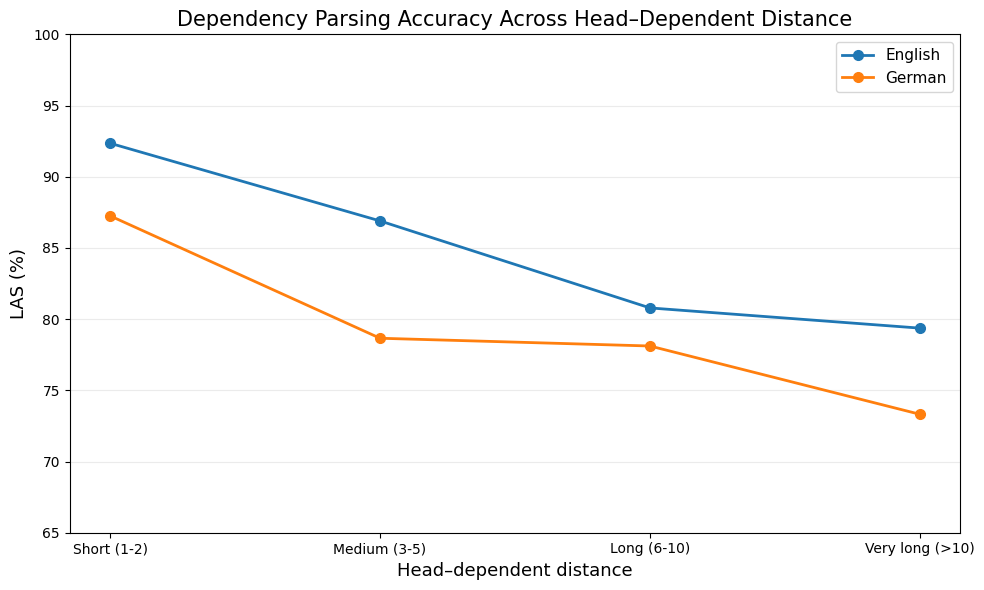

In [ ]:
import matplotlib.pyplot as plt

main_plot = (
    final_results
    .groupby(["language", "distance_category"])["LAS_binary"]
    .mean()
    .mul(100)
    .reset_index()
)

order = [
    "Short (1-2)",
    "Medium (3-5)",
    "Long (6-10)",
    "Very long (>10)"
]

main_plot["distance_category"] = pd.Categorical(
    main_plot["distance_category"],
    categories=order,
    ordered=True
)

main_plot = main_plot.sort_values(
    ["language", "distance_category"]
)


plt.figure(figsize=(10, 6))

for language in ["English", "German"]:
    data = main_plot[
        main_plot["language"] == language
    ]

    plt.plot(
        data["distance_category"],
        data["LAS_binary"],
        marker="o",
        linewidth=2,
        markersize=7,
        label=language
    )

plt.xlabel("Head–dependent distance", fontsize=13)
plt.ylabel("LAS (%)", fontsize=13)
plt.title(
    "Dependency Parsing Accuracy Across Head–Dependent Distance",
    fontsize=15
)

plt.ylim(65, 100)
plt.grid(axis="y", alpha=0.25)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [ ]:
metric_data = (
    final_results
    .groupby("language")[["UAS_correct", "LAS_binary"]]
    .mean()
    .mul(100)
    .reset_index()
)

metric_data = metric_data.rename(
    columns={
        "UAS_correct": "UAS",
        "LAS_binary": "LAS"
    }
)

display(metric_data)

,language,UAS,LAS
0,English,92.031976,89.555546
1,German,87.456513,83.191599


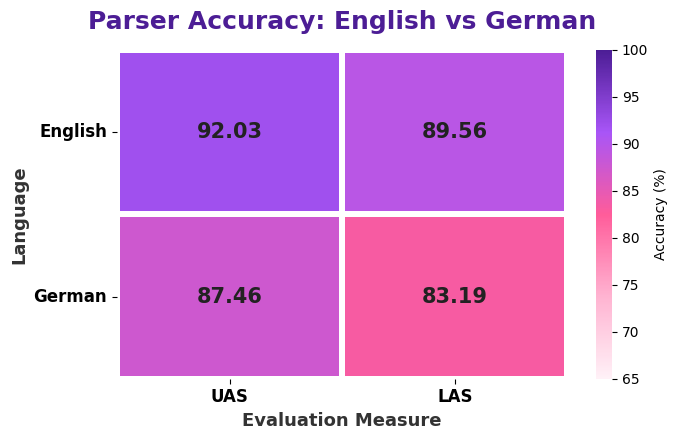

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap


heatmap_data = metric_data.set_index("language")[["UAS", "LAS"]]


colors = [
    "#FFF1F7",   # very light pink
    "#FFB3D1",   # soft pink
    "#FF5C9A",   # pink
    "#A855F7",   # purple
    "#4C1D95"    # dark purple
]

custom_cmap = LinearSegmentedColormap.from_list(
    "poster_heatmap",
    colors
)


plt.figure(figsize=(7, 4.5))

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt=".2f",
    cmap=custom_cmap,
    linewidths=4,
    linecolor="white",
    cbar_kws={
        "label": "Accuracy (%)"
    },
    annot_kws={
        "fontsize": 15,
        "fontweight": "bold",
        "color": "#222222"
    },
    vmin=65,
    vmax=100
)

plt.title(
    "Parser Accuracy: English vs German",
    fontsize=18,
    fontweight="bold",
    color="#4C1D95",
    pad=15
)

plt.xlabel(
    "Evaluation Measure",
    fontsize=13,
    fontweight="bold",
    color="#333333"
)

plt.ylabel(
    "Language",
    fontsize=13,
    fontweight="bold",
    color="#333333"
)

plt.xticks(
    fontsize=12,
    fontweight="bold"
)

plt.yticks(
    fontsize=12,
    fontweight="bold",
    rotation=0
)

plt.tight_layout()

plt.savefig(
    "overall_performance.png",
    dpi=300,
    bbox_inches="tight",
    facecolor="white"
)

plt.show()

In [ ]:
top_relations = (
    frequent_relations
    .sort_values("Error (%)", ascending=False)
    .head(6)
    .copy()
)

top_relations["label"] = (
    top_relations["language"]
    + " – "
    + top_relations["gold_relation"]
)

display(
    top_relations[
        [
            "label",
            "dependencies",
            "LAS (%)",
            "Error (%)"
        ]
    ]
)

,label,dependencies,LAS (%),Error (%)
59,German – compound,228,32.02,67.98
43,English – parataxis,232,44.83,55.17
6,English – appos,148,56.08,43.92
28,English – list,290,57.24,42.76
53,German – appos,240,58.33,41.67
33,English – nmod:unmarked,111,58.56,41.44


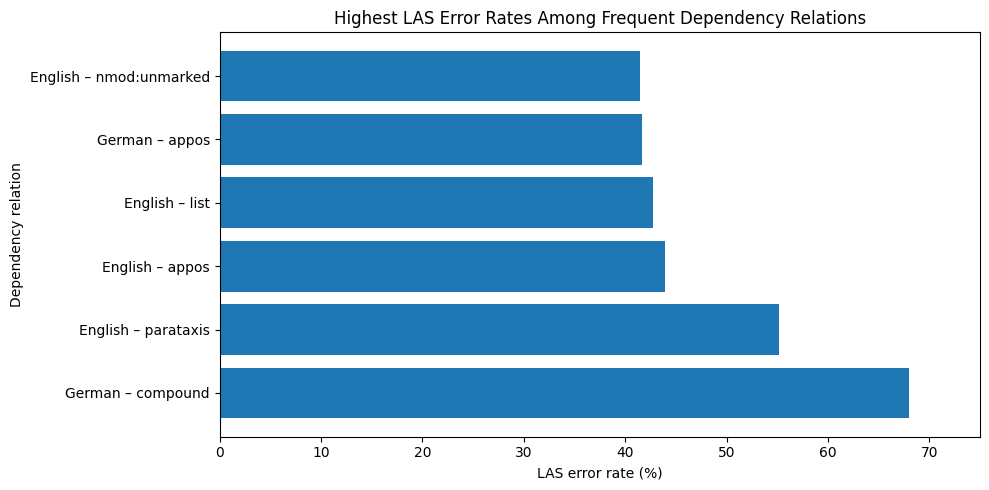

In [ ]:
plt.figure(figsize=(10, 5))

plt.barh(
    top_relations["label"],
    top_relations["Error (%)"]
)

plt.xlabel("LAS error rate (%)")
plt.ylabel("Dependency relation")
plt.title(
    "Highest LAS Error Rates Among Frequent Dependency Relations"
)

plt.xlim(0, 75)
plt.tight_layout()
plt.show()